# Анализ эффективности пролонгации договоров (2023) для отдела сопровождения клиентов Topface Media



**Цели проекта:**  
- Оценить результативность каждого аккаунт-менеджера и отдела в целом по возврату завершённых проектов.  
- На основе двухступенчатого коэффициента пролонгации (месяц 1 и месяц 2) выявить точки роста.  
- Предоставить руководителю наглядный отчёт для принятия управленческих решений.

**Структура проекта:**  
1. **Загрузка и интеграция данных** — объединение `prolongations.csv` и `financial_data.csv` с учётом приоритета ответственного менеджера.  
2. **Предобработка** — устранение дублей, трансформация финансовых данных в длинный формат, проверка корректности периодов.  
3. **Расчёт коэффициентов пролонгации** — реализация двухшаговой логики (помесячно и за год) для каждого менеджера и всего отдела.  
4. **Сборка аналитического отчёта** — таблицы с коэффициентами, сводные срезы, визуализация динамики.  
5. **Интерпретация результатов** — выводы и рекомендации для руководителя.

## Загрузка и предобработка

### Импорт библиотек и загрузка данных


In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import os
import matplotlib.pyplot as plt
import seaborn as sns


# Загружаем CSV из текущей директории (Google Colab обычно /content)
current_dir = os.getcwd()
prolongations = pd.read_csv(os.path.join(current_dir, 'prolongations.csv'))
financial_data = pd.read_csv(os.path.join(current_dir, 'financial_data.csv'))

prolongations.info()
display(prolongations.head())
financial_data.info()
display(financial_data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 477 entries, 0 to 476
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      477 non-null    int64 
 1   month   477 non-null    object
 2   AM      477 non-null    object
dtypes: int64(1), object(2)
memory usage: 11.3+ KB


,id,month,AM
0,42,ноябрь 2022,Васильев Артем Александрович
1,453,ноябрь 2022,Васильев Артем Александрович
2,548,ноябрь 2022,Михайлов Андрей Сергеевич
3,87,ноябрь 2022,Соколова Анастасия Викторовна
4,429,ноябрь 2022,Соколова Анастасия Викторовна


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 451 entries, 0 to 450
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             451 non-null    int64 
 1   Причина дубля  301 non-null    object
 2   Ноябрь 2022    156 non-null    object
 3   Декабрь 2022   159 non-null    object
 4   Январь 2023    139 non-null    object
 5   Февраль 2023   145 non-null    object
 6   Март 2023      168 non-null    object
 7   Апрель 2023    174 non-null    object
 8   Май 2023       190 non-null    object
 9   Июнь 2023      190 non-null    object
 10  Июль 2023      195 non-null    object
 11  Август 2023    199 non-null    object
 12  Сентябрь 2023  186 non-null    object
 13  Октябрь 2023   182 non-null    object
 14  Ноябрь 2023    171 non-null    object
 15  Декабрь 2023   146 non-null    object
 16  Январь 2024    95 non-null     object
 17  Февраль 2024   101 non-null    object
 18  Account        451 non-null   

,id,Причина дубля,Ноябрь 2022,Декабрь 2022,Январь 2023,Февраль 2023,Март 2023,Апрель 2023,Май 2023,Июнь 2023,Июль 2023,Август 2023,Сентябрь 2023,Октябрь 2023,Ноябрь 2023,Декабрь 2023,Январь 2024,Февраль 2024,Account
0,42,NaN,"36 220,00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
1,657,первая часть оплаты,стоп,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
2,657,вторая часть оплаты,стоп,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
3,594,NaN,стоп,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович
4,665,NaN,"10 000,00",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Васильев Артем Александрович


### Парсинг русских названий месяцев


In [2]:
# Словарь для перевода названий месяцев в номера
MONTHS_RU = {
    'январь': 1, 'февраль': 2, 'март': 3, 'апрель': 4,
    'май': 5, 'июнь': 6, 'июль': 7, 'август': 8,
    'сентябрь': 9, 'октябрь': 10, 'ноябрь': 11, 'декабрь': 12
}

def parse_ru_month(date_str):
    """'ноябрь 2022' -> datetime(2022,11,1)"""
    parts = date_str.strip().split()
    month = parts[0].lower()
    year = int(parts[1])
    return datetime(year, MONTHS_RU[month], 1)

# Применяем к prolongations
prolongations['month_dt'] = prolongations['month'].apply(parse_ru_month)

# Задаём хронологический список колонок с месяцами из financial_data
MONTH_COLS = [
    'Ноябрь 2022', 'Декабрь 2022',
    'Январь 2023', 'Февраль 2023', 'Март 2023', 'Апрель 2023',
    'Май 2023', 'Июнь 2023', 'Июль 2023', 'Август 2023',
    'Сентябрь 2023', 'Октябрь 2023', 'Ноябрь 2023', 'Декабрь 2023',
    'Январь 2024', 'Февраль 2024'
]

### Очистка сумм с сохранением информации о «стоп»/«end»

In [3]:
def clean_amount_keep_stop(val):
    """Возвращает число, 0.0, np.nan или строку 'STOP' для 'стоп'/'end'."""
    if pd.isna(val):
        return np.nan
    s = str(val).strip().lower()
    if s in ('стоп', 'end'):
        return 'STOP'          # маркер для последующей фильтрации
    if s == 'в ноль':
        return 0.0
    s_clean = s.replace('\xa0', '').replace(' ', '').replace(',', '.')
    try:
        return float(s_clean)
    except ValueError:
        return np.nan

# Применяем
df_fin = financial_data.copy()
for col in MONTH_COLS:
    df_fin[col] = df_fin[col].apply(clean_amount_keep_stop)

print("После очистки (пример):")
print(df_fin[['id', 'Ноябрь 2022']].head(10))

После очистки (пример):
    id Ноябрь 2022
0   42     36220.0
1  657        STOP
2  657        STOP
3  594        STOP
4  665     10000.0
5  637     38045.0
6  419         NaN
7  578     82800.0
8  579         0.0
9  592     92302.0


### Исключение проектов со «стоп»/«end»
Теперь ищем 'STOP' только в месяцах ≤ month_dt. Если есть хотя бы одно такое значение – проект исключается.

In [4]:
# 1. Присоединяем дату завершения проекта из prolongations
df_fin = df_fin.merge(prolongations[['id', 'month_dt']], on='id', how='left')

# 2. Переводим в длинный формат: каждая строка — (id, месяц, значение)
melted = df_fin.melt(
    id_vars=['id', 'month_dt'],
    value_vars=MONTH_COLS,
    var_name='shipment_month',
    value_name='amount'
)

# 3. Парсим месяц отгрузки в datetime для сравнения
melted['shipment_dt'] = melted['shipment_month'].apply(parse_ru_month)

# 4. Оставляем только месяцы ≤ month_dt (до завершения проекта включительно)
valid = melted[melted['shipment_dt'] <= melted['month_dt']]

# 5. Находим id, у которых в этом периоде есть 'STOP'
stop_ids = valid.loc[valid['amount'] == 'STOP', 'id'].unique()

print(f" исключено проектов со стоп/end: {len(stop_ids)}")
if len(stop_ids) > 0:
    print(f"Примеры ID: {sorted(stop_ids)[:20]}")

# 6. Удаляем строки этих проектов
df_clean = df_fin[~df_fin['id'].isin(stop_ids)].copy()

# 7. Заменяем оставшиеся 'STOP' (если есть после month_dt) на 0.0
for col in MONTH_COLS:
    df_clean.loc[:, col] = df_clean[col].mask(df_clean[col] == 'STOP', 0.0)

# 8. Приводим все колонки месяцев к float
for col in MONTH_COLS:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').fillna(0.0)

print(f"Строк после фильтрации: {len(df_clean)} (было {len(df_fin)})")
print(f"Уникальных id после фильтрации: {df_clean['id'].nunique()}")

 исключено проектов со стоп/end: 46
Примеры ID: [np.int64(83), np.int64(101), np.int64(180), np.int64(199), np.int64(244), np.int64(369), np.int64(418), np.int64(456), np.int64(457), np.int64(460), np.int64(477), np.int64(519), np.int64(556), np.int64(562), np.int64(572), np.int64(573), np.int64(574), np.int64(575), np.int64(576), np.int64(594)]
Строк после фильтрации: 630 (было 726)
Уникальных id после фильтрации: 268


### Агрегация дублей и определение ответственного менеджера
Суммируем все строки с одинаковым id по каждому месяцу.
AM берём из prolongations (приоритет), иначе из financial_data.Account, иначе "без А/М".



In [5]:
# 1. Суммируем отгрузки по id и месяцам
sum_cols = ['id'] + MONTH_COLS
df_sums = df_clean[sum_cols].groupby('id').sum().reset_index()

# 2. Строим отображение id -> AM_final
am_prol = prolongations[['id', 'AM']].drop_duplicates(subset='id')
am_fin = financial_data[['id', 'Account']].drop_duplicates(subset='id')
am_map = am_prol.merge(am_fin, on='id', how='outer')
am_map['AM_final'] = am_map['AM'].fillna(am_map['Account']).fillna('без А/М')
am_map = am_map[['id', 'AM_final']]

# 3. Берём month_dt из prolongations
month_info = prolongations[['id', 'month_dt']].drop_duplicates(subset='id')

# 4. Присоединяем AM_final и month_dt к суммам
df_agg = df_sums.merge(am_map, on='id', how='left')
df_agg = df_agg.merge(month_info, on='id', how='left')

print(f"Проектов: {len(df_agg)}")
print(f"Менеджеров: {df_agg['AM_final'].nunique()}")
print(df_agg['AM_final'].value_counts())

Этап 5 завершён. Проектов: 268
Менеджеров: 10
AM_final
Васильев Артем Александрович     70
Попова Екатерина Николаевна      51
Соколова Анастасия Викторовна    46
Смирнова Ольга Владимировна      36
Иванова Мария Сергеевна          33
Михайлов Андрей Сергеевич        20
Кузнецов Михаил Иванович          8
без А/М                           2
Федорова Марина Васильевна        1
Петрова Анна Дмитриевна           1
Name: count, dtype: int64


### Перевод в длинный формат для расчёта коэффициентов



In [6]:
id_vars = ['id', 'AM_final', 'month_dt']
df_long = df_agg.melt(
    id_vars=id_vars,
    value_vars=MONTH_COLS,
    var_name='shipment_month_str',
    value_name='amount'
)

# Парсим месяц отгрузки
df_long['shipment_month'] = df_long['shipment_month_str'].apply(parse_ru_month)

# Переименовываем для удобства
df_long.rename(columns={'month_dt': 'end_month'}, inplace=True)

print(f"Длинный формат: {len(df_long)} строк")
print("Пример:")
display(df_long.head())

Длинный формат: 4288 строк
Пример:


,id,AM_final,end_month,shipment_month_str,amount,shipment_month
0,15,Иванова Мария Сергеевна,2022-12-01,Ноябрь 2022,2196400.0,2022-11-01
1,16,Иванова Мария Сергеевна,2022-12-01,Ноябрь 2022,0.0,2022-11-01
2,31,Васильев Артем Александрович,2022-12-01,Ноябрь 2022,55100.0,2022-11-01
3,39,Иванова Мария Сергеевна,2022-12-01,Ноябрь 2022,275400.0,2022-11-01
4,42,Васильев Артем Александрович,2022-11-01,Ноябрь 2022,36220.0,2022-11-01


## Расчёт коэффициентов 

### Расчёт K1 и K2 по месяцам

Для каждого месяца T (с января по декабрь 2023) считаем два коэффициента.

**K1 — пролонгация в первый месяц после завершения.**  
Берём проекты, завершившиеся в T‑1 (предыдущий месяц).  
Знаменатель — сумма их отгрузок в этом последнем месяце. Если там «в ноль» (сумма 0), берём отгрузку ближайшего более раннего месяца с ненулевой суммой.  
Числитель — сумма отгрузок этих же проектов в месяце T.  
K1 = числитель / знаменатель.

**K2 — пролонгация во второй месяц после завершения.**  
Берём проекты, завершившиеся в T‑2 (два месяца назад).  
Из них исключаем те, у которых была **положительная** отгрузка в T‑1 (они уже продлились в первом месяце). Если отгрузка в T‑1 нулевая или «в ноль», проект остаётся.  
Знаменатель — сумма отгрузок оставшихся проектов в T‑2 (с тем же правилом подстановки при «в ноль»).  
Числитель — сумма их отгрузок в T.  
K2 = числитель / знаменатель.

Если знаменатель равен нулю, коэффициент не определён (None).

Результат собирается в таблицу `koef_df` с разбивкой по менеджерам и итогом по отделу.



In [18]:
# Вспомогательная: предыдущий месяц
def prev_month(dt):
    if dt.month == 1:
        return datetime(dt.year - 1, 12, 1)
    return datetime(dt.year, dt.month - 1, 1)

# Вспомогательная: поиск последней ненулевой отгрузки для группы проектов
def get_last_nonzero(df, proj_ids, target_month):
    cur = target_month
    while cur >= df['shipment_month'].min():
        s = df[(df['id'].isin(proj_ids)) & (df['shipment_month'] == cur)]['amount'].sum()
        if s > 0:
            return s
        cur = prev_month(cur)
    return 0.0

# Месяцы пролонгации: январь–декабрь 2023
prolong_months = [datetime(2023, m, 1) for m in range(1, 13)]
rows = []

for T in prolong_months:
    T_str = T.strftime('%Y-%m')
    
    # ========== K1 ==========
    end_m1 = prev_month(T)                          # месяц завершения проектов для K1
    proj_m1 = df_long[df_long['end_month'] == end_m1]
    ids_m1 = proj_m1['id'].unique()
    
    denom_k1 = get_last_nonzero(df_long, ids_m1, end_m1)
    num_k1 = proj_m1[proj_m1['shipment_month'] == T]['amount'].sum()
    k1_proj_count = proj_m1[
        (proj_m1['shipment_month'] == T) & (proj_m1['amount'] > 0)
    ]['id'].nunique()
    
    # ========== K2 ==========
    end_m2 = prev_month(end_m1)                     # месяц завершения проектов для K2
    proj_m2 = df_long[df_long['end_month'] == end_m2]
    
    # Исключаем тех, у кого была положительная отгрузка в T-1
    positive_m1 = df_long[
        (df_long['shipment_month'] == end_m1) &
        (df_long['amount'] > 0) &
        (df_long['id'].isin(proj_m2['id']))
    ]['id'].unique()
    
    proj_m2_clean = proj_m2[~proj_m2['id'].isin(positive_m1)]
    ids_m2 = proj_m2_clean['id'].unique()
    
    denom_k2 = get_last_nonzero(df_long, ids_m2, end_m2)
    num_k2 = proj_m2_clean[proj_m2_clean['shipment_month'] == T]['amount'].sum()
    k2_proj_count = proj_m2_clean[
        (proj_m2_clean['shipment_month'] == T) & (proj_m2_clean['amount'] > 0)
    ]['id'].nunique()
    
    # ========== Запись: весь отдел ==========
    rows.append({
        'month': T_str, 'AM': 'Все',
        'K1_num': num_k1, 'K1_denom': denom_k1,
        'K1': num_k1 / denom_k1 if denom_k1 > 0 else None,
        'K2_num': num_k2, 'K2_denom': denom_k2,
        'K2': num_k2 / denom_k2 if denom_k2 > 0 else None,
        'K1_proj_count': k1_proj_count,
        'K2_proj_count': k2_proj_count
    })
    
    # ========== Запись: по менеджерам ==========
    for am in df_long['AM_final'].unique():
        # K1 для менеджера
        p1 = proj_m1[proj_m1['AM_final'] == am]
        ids1 = p1['id'].unique()
        d1 = get_last_nonzero(df_long, ids1, end_m1)
        n1 = p1[p1['shipment_month'] == T]['amount'].sum()
        c1 = p1[(p1['shipment_month'] == T) & (p1['amount'] > 0)]['id'].nunique()
        
        # K2 для менеджера
        p2 = proj_m2_clean[proj_m2_clean['AM_final'] == am]
        ids2 = p2['id'].unique()
        d2 = get_last_nonzero(df_long, ids2, end_m2)
        n2 = p2[p2['shipment_month'] == T]['amount'].sum()
        c2 = p2[(p2['shipment_month'] == T) & (p2['amount'] > 0)]['id'].nunique()
        
        rows.append({
            'month': T_str, 'AM': am,
            'K1_num': n1, 'K1_denom': d1,
            'K1': n1 / d1 if d1 > 0 else None,
            'K2_num': n2, 'K2_denom': d2,
            'K2': n2 / d2 if d2 > 0 else None,
            'K1_proj_count': c1,
            'K2_proj_count': c2
        })

koef_df = pd.DataFrame(rows)
print("Финальные коэффициенты по месяцам:")
display(koef_df.head())

Финальные коэффициенты по месяцам:


,month,AM,K1_num,K1_denom,K1,K2_num,K2_denom,K2,K1_proj_count,K2_proj_count
0,2023-01,Все,8704856.80,14538934.25,0.598727,146760.0,667312.0,0.219927,22,1
1,2023-01,Иванова Мария Сергеевна,1679173.42,4967615.71,0.338024,0.0,104480.0,0.000000,4,0
2,2023-01,Васильев Артем Александрович,3864948.20,5418285.36,0.713316,0.0,260862.0,0.000000,6,0
3,2023-01,Попова Екатерина Николаевна,443530.00,577195.00,0.768423,0.0,82800.0,0.000000,2,0
4,2023-01,Смирнова Ольга Владимировна,384335.00,427800.00,0.898399,0.0,0.0,NaN,2,0


### Годовые коэффициенты


In [8]:
# 1. Годовые коэффициенты (по суммам)
yearly = koef_df.groupby('AM').agg(
    K1_num_sum=('K1_num', 'sum'),
    K1_denom_sum=('K1_denom', 'sum'),
    K2_num_sum=('K2_num', 'sum'),
    K2_denom_sum=('K2_denom', 'sum')
).reset_index()

yearly['K1_year'] = yearly['K1_num_sum'] / yearly['K1_denom_sum'].replace(0, np.nan)
yearly['K2_year'] = yearly['K2_num_sum'] / yearly['K2_denom_sum'].replace(0, np.nan)

# 2. Количество пролонгаций (по проектам) за год
proj_counts = koef_df.groupby('AM').agg(
    K1_proj_total=('K1_proj_count', 'sum'),
    K2_proj_total=('K2_proj_count', 'sum')
).reset_index()

# 3. Объединяем
yearly = yearly.merge(proj_counts, on='AM', how='left')

print("Годовые коэффициенты пролонгации:")
display(yearly[['AM', 'K1_year', 'K2_year', 'K1_proj_total', 'K2_proj_total']])

Годовые коэффициенты пролонгации:


,AM,K1_year,K2_year,K1_proj_total,K2_proj_total
0,Васильев Артем Александрович,0.579772,0.175067,20,6
1,Все,0.578565,0.127684,82,14
2,Иванова Мария Сергеевна,0.306162,0.000000,8,0
3,Кузнецов Михаил Иванович,0.602542,0.000000,3,0
4,Михайлов Андрей Сергеевич,0.858315,0.000000,9,0
5,Петрова Анна Дмитриевна,1.111182,NaN,1,0
6,Попова Екатерина Николаевна,0.629524,0.094478,16,2
7,Смирнова Ольга Владимировна,0.751128,0.242524,11,3
8,Соколова Анастасия Викторовна,0.636230,0.130633,14,3
9,Федорова Марина Васильевна,NaN,NaN,0,0


K1_proj_total	Сколько раз за год проекты менеджера получали отгрузку в первый месяц после завершения.

K2_proj_total	Сколько раз за год проекты менеджера, пропустившие первый месяц, получали отгрузку во второй месяц после завершения.

 K1_year — эффективность пролонгации в 1-й месяц

| Менеджер | K1_year | Пролонгировано проектов |
|----------|---------|------------------------|
| Петрова | 111% | 1 |
| Михайлов | 86% | 9 |
| Смирнова | 75% | 11 |
| Соколова | 64% | 14 |
| Кузнецов | 60% | 3 |
| Попова | 63% | 16 |
| **Все** | **58%** | **82** |
| Васильев | 58% | 20 |
| Иванова | 31% | 8 |

Лидеры: Михайлов, Смирнова.  
Аутсайдер: Иванова (31% — в 2 раза ниже среднего).  
Петрова > 100% — её единственный проект дал в пролонгации больше, чем в последнем месяце.

---

 K2_year — догоняющая пролонгация (2-й месяц)

| Менеджер | K2_year | Проектов |
|----------|---------|----------|
| Смирнова | 24% | 3 |
| Васильев | 18% | 6 |
| Соколова | 13% | 3 |
| Попова | 9% | 2 |
| **Все** | **13%** | **14** |
| Остальные | 0% или NaN | 0 |

Только 4 менеджера из 8 догоняют клиентов во втором месяце.  
Общий K2 = 13% — слабый результат.

---

### Выводы 

1. **Основная пролонгация — в 1-й месяц (K1 = 58%).** Это рабочий инструмент, можно ставить KPI.
2. **K2 почти не работает** (13% по отделу, у половины менеджеров — 0). Клиенты, не продлившиеся сразу, теряются.
3. **Иванова — проблемная зона:** K1 = 31%, K2 = 0. Нужен разбор её клиентов.
4. **Методику K2 можно пересмотреть** — расширить окно до 3 или 6 месяцев.

---



## Построение отчетных таблиц


### Весь отдел

In [9]:
sheet1_rows = []

managers = ['Все'] + sorted([am for am in koef_df['AM'].unique() if am != 'Все'])

for am in managers:
    sheet1_rows.append({
        'Месяц': am,
        'к пролонгации K1': '', 'Пролонгировано K1': '', 'Коэффициент K1': '',
        'к пролонгации K2': '', 'Пролонгировано K2': '', 'Коэффициент K2': ''
    })
    
    am_data = koef_df[koef_df['AM'] == am].sort_values('month')
    for _, r in am_data.iterrows():
        sheet1_rows.append({
            'Месяц': r['month'],
            'к пролонгации K1': r['K1_denom'],
            'Пролонгировано K1': r['K1_num'],
            'Коэффициент K1': round(r['K1'], 2) if pd.notna(r['K1']) else '',
            'к пролонгации K2': r['K2_denom'],
            'Пролонгировано K2': r['K2_num'],
            'Коэффициент K2': round(r['K2'], 2) if pd.notna(r['K2']) else ''
        })
    
    sheet1_rows.append({
        'Месяц': '', 'к пролонгации K1': '', 'Пролонгировано K1': '', 'Коэффициент K1': '',
        'к пролонгации K2': '', 'Пролонгировано K2': '', 'Коэффициент K2': ''
    })

df_sheet1 = pd.DataFrame(sheet1_rows)

with pd.ExcelWriter('Prolongation_Report_2023.xlsx', engine='openpyxl') as writer:
    df_sheet1.to_excel(writer, sheet_name='Весь отдел', index=False)

df_sheet1.head(40)

,Месяц,к пролонгации K1,Пролонгировано K1,Коэффициент K1,к пролонгации K2,Пролонгировано K2,Коэффициент K2
0,Все,,,,,,
1,2023-01,14538934.25,8704856.8,0.6,667312.0,146760.0,0.22
2,2023-02,894420.5,137155.0,0.15,4356182.76,676470.0,0.16
3,2023-03,1688680.3,1325608.95,0.78,733335.5,326321.32,0.44
4,2023-04,3191255.9,1602695.7,0.5,396790.0,53220.0,0.13
5,2023-05,2279577.0,1696279.5,0.74,1834211.7,0.0,0.0
6,2023-06,1130356.53,209536.0,0.19,1043577.0,77265.0,0.07
7,2023-07,1371536.1,776740.0,0.57,920820.53,147185.0,0.16
8,2023-08,1436193.33,566663.88,0.39,784901.1,0.0,0.0
9,2023-09,2724746.65,1375570.84,0.5,711187.13,0.0,0.0


Сумма отгрузок в декабре 2022 для проектов, завершённых в декабре 2022:
Общая сумма: 14,538,934.25
Количество проектов: 52

Топ-10 проектов по сумме отгрузки в декабре:


id
708    2509475.00
15     2196400.00
719    1807110.00
112     970250.00
274     851340.00
597     420030.42
154     345270.00
524     296130.71
697     284000.00
281     279750.00
Name: amount, dtype: float64


Сумма отгрузок в январе 2023 для тех же проектов:
Общая сумма: 8,704,856.80
Количество проектов: 52


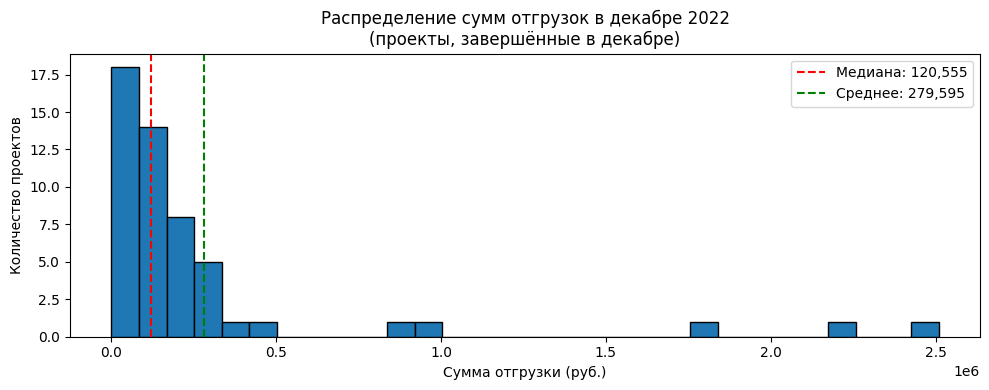


Знаменатели K1 по месяцам (весь отдел):
month
2023-01    14538934.25
2023-02      894420.50
2023-03     1688680.30
2023-04     3191255.90
2023-05     2279577.00
2023-06     1130356.53
2023-07     1371536.10
2023-08     1436193.33
2023-09     2724746.65
2023-10     1994175.40
2023-11     1754090.97
2023-12     1119808.06
Name: K1_denom, dtype: float64


In [10]:
# ------------------------------------------------------------
# Проверка аномалии января 2023 (K1): проекты, завершившиеся в декабре 2022
# ------------------------------------------------------------
dec_projects = df_long[df_long['end_month'] == '2022-12-01']

# Отгрузки в декабре (знаменатель K1 для января)
ship_dec = dec_projects[dec_projects['shipment_month'] == '2022-12-01']
print("Сумма отгрузок в декабре 2022 для проектов, завершённых в декабре 2022:")
print(f"Общая сумма: {ship_dec['amount'].sum():,.2f}")
print(f"Количество проектов: {ship_dec['id'].nunique()}")
print("\nТоп-10 проектов по сумме отгрузки в декабре:")
display(ship_dec.groupby('id')['amount'].sum().sort_values(ascending=False).head(10))

# Отгрузки в январе (числитель K1 для января)
ship_jan = dec_projects[dec_projects['shipment_month'] == '2023-01-01']
print("\nСумма отгрузок в январе 2023 для тех же проектов:")
print(f"Общая сумма: {ship_jan['amount'].sum():,.2f}")
print(f"Количество проектов: {ship_jan['id'].nunique()}")

# ------------------------------------------------------------
# Проверка: нет ли в знаменателе проектов со стоп/end (должны быть исключены)
# ------------------------------------------------------------
# Убедимся, что в df_long отсутствуют проекты, помеченные как стоп в этапе 4
# (если они были удалены корректно, то в ship_dec их быть не должно)
# ------------------------------------------------------------

# ------------------------------------------------------------
# Гистограмма сумм отгрузок в декабре 2022 (знаменатель K1 января)
# ------------------------------------------------------------
import matplotlib.pyplot as plt
dec_sums = ship_dec.groupby('id')['amount'].sum()
plt.figure(figsize=(10, 4))
plt.hist(dec_sums, bins=30, edgecolor='black')
plt.title('Распределение сумм отгрузок в декабре 2022\n(проекты, завершённые в декабре)')
plt.xlabel('Сумма отгрузки (руб.)')
plt.ylabel('Количество проектов')
plt.axvline(dec_sums.median(), color='red', linestyle='--', label=f'Медиана: {dec_sums.median():,.0f}')
plt.axvline(dec_sums.mean(), color='green', linestyle='--', label=f'Среднее: {dec_sums.mean():,.0f}')
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Сравнение с другими месяцами: знаменатели K1 за весь год
# ------------------------------------------------------------
monthly_denom = koef_df[koef_df['AM'] == 'Все'].set_index('month')['K1_denom']
print("\nЗнаменатели K1 по месяцам (весь отдел):")
print(monthly_denom)

### Менеджеры за год

In [11]:

year_rows = []
for _, r in yearly.iterrows():
    year_rows.append({
        'Менеджер': r['AM'],
        'к пролонгированию K1': r['K1_denom_sum'],
        'Пролонгировано K1': r['K1_num_sum'],
        'Коэффициент K1': round(r['K1_year'], 2) if pd.notna(r['K1_year']) else '',
        'к пролонгированию K2': r['K2_denom_sum'],
        'Пролонгировано K2': r['K2_num_sum'],
        'Коэффициент K2': round(r['K2_year'], 2) if pd.notna(r['K2_year']) else ''
    })

df_year = pd.DataFrame(year_rows)

# "Все" в конец
if 'Все' in df_year['Менеджер'].values:
    mask_all = df_year['Менеджер'] == 'Все'
    df_year = pd.concat([df_year[~mask_all], df_year[mask_all]], ignore_index=True)

# Сохраняем
with pd.ExcelWriter('Prolongation_Report_2023.xlsx', engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
    df_year.to_excel(writer, sheet_name='Менеджеры за год', index=False)

df_year

,Менеджер,к пролонгированию K1,Пролонгировано K1,Коэффициент K1,к пролонгированию K2,Пролонгировано K2,Коэффициент K2
0,Васильев Артем Александрович,12238585.26,7095594.95,0.58,6458771.80,1130716.32,0.18
1,Иванова Мария Сергеевна,6331135.41,1938352.30,0.31,2342553.50,0.00,0.0
2,Кузнецов Михаил Иванович,813387.53,490100.00,0.6,1425.00,0.00,0.0
3,Михайлов Андрей Сергеевич,2295503.00,1970264.58,0.86,845140.18,0.00,0.0
4,Петрова Анна Дмитриевна,98492.00,109442.52,1.11,0.00,0.00,
5,Попова Екатерина Николаевна,3972215.90,2500605.40,0.63,1386775.26,131020.00,0.09
6,Смирнова Ольга Владимировна,2701279.68,2029006.65,0.75,735639.35,178410.00,0.24
7,Соколова Анастасия Викторовна,5673176.21,3609444.94,0.64,2238753.01,292455.00,0.13
8,Федорова Марина Васильевна,0.00,0.00,,0.00,0.00,
9,без А/М,0.00,0.00,,0.00,0.00,


### Менеджеры по месяцам

In [12]:
# Таблица K1
pivot_k1 = koef_df.pivot_table(
    index='AM', columns='month', values='K1', aggfunc='first'
).round(2).fillna('')

# Таблица K2
pivot_k2 = koef_df.pivot_table(
    index='AM', columns='month', values='K2', aggfunc='first'
).round(2).fillna('')

# Функция, переносящая "Все" в конец списка
def move_all_to_end(df):
    if 'Все' in df.index:
        idx = list(df.index)
        idx.remove('Все')
        idx.append('Все')
        df = df.loc[idx]
    return df

pivot_k1 = move_all_to_end(pivot_k1)
pivot_k2 = move_all_to_end(pivot_k2)

# Сохраняем
with pd.ExcelWriter('Prolongation_Report_2023.xlsx', engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
    pivot_k1.to_excel(writer, sheet_name='K1 Менеджеры по месяцам')
    pivot_k2.to_excel(writer, sheet_name='K2 Менеджеры по месяцам')

print("Листы 'K1 Менеджеры по месяцам' и 'K2 Менеджеры по месяцам' обновлены.")
display(pivot_k1)
display(pivot_k2)

Листы 'K1 Менеджеры по месяцам' и 'K2 Менеджеры по месяцам' обновлены.


month,2023-01,2023-02,2023-03,2023-04,2023-05,2023-06,2023-07,2023-08,2023-09,2023-10,2023-11,2023-12
AM,,,,,,,,,,,,
Васильев Артем Александрович,0.71,0.0,0.83,0.15,0.34,0.48,1.33,0.3,0.25,0.0,0.8,0.0
Иванова Мария Сергеевна,0.34,,0.0,0.0,,0.0,0.54,0.45,1.0,,,
Кузнецов Михаил Иванович,1.27,,,0.0,,,,,,,0.93,0.0
Михайлов Андрей Сергеевич,0.79,,2.43,1.07,1.33,0.0,1.2,,,0.0,,0.0
Петрова Анна Дмитриевна,,,,,,,,,,,,1.11
Попова Екатерина Николаевна,0.77,0.0,0.0,0.24,0.92,0.0,0.17,0.55,0.98,0.71,,0.6
Смирнова Ольга Владимировна,0.9,0.0,,1.0,,0.0,,0.36,0.66,1.21,0.96,0.07
Соколова Анастасия Викторовна,0.64,0.27,1.16,1.2,0.0,0.0,0.11,0.51,0.63,0.91,0.27,0.15
Все,0.6,0.15,0.78,0.5,0.74,0.19,0.57,0.39,0.5,0.88,0.78,0.2


month,2023-01,2023-02,2023-03,2023-04,2023-05,2023-06,2023-07,2023-08,2023-09,2023-10,2023-11,2023-12
AM,,,,,,,,,,,,
Васильев Артем Александрович,0.0,0.23,1.94,0.0,0.0,0.11,0.0,0.0,0.0,0.16,0.0,0.89
Иванова Мария Сергеевна,0.0,0.0,,0.0,0.0,,0.0,0.0,,,,
Кузнецов Михаил Иванович,,,,,0.0,,,,,,,
Михайлов Андрей Сергеевич,0.0,0.0,,,,0.0,0.0,,,,0.0,
Попова Екатерина Николаевна,0.0,0.0,0.0,0.43,0.0,0.0,1.95,0.0,0.0,,0.0,
Смирнова Ольга Владимировна,,0.0,1.15,,,,0.52,,0.0,0.0,0.0,0.77
Соколова Анастасия Викторовна,0.82,0.29,0.0,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Все,0.22,0.16,0.44,0.13,0.0,0.07,0.16,0.0,0.0,0.12,0.0,0.39


### Качество работы менеджера (с учётом количества контрактов)

In [13]:
# 1. Общее число проектов за 2023 год по менеджерам
projects_2023 = df_agg[(df_agg['month_dt'] >= '2023-01-01') & (df_agg['month_dt'] <= '2023-12-01')]
total_projects = projects_2023.groupby('AM_final')['id'].nunique().reset_index()
total_projects.columns = ['AM', 'total_projects_2023']

all_projects = pd.DataFrame([{'AM': 'Все', 'total_projects_2023': projects_2023['id'].nunique()}])
total_projects = pd.concat([total_projects, all_projects], ignore_index=True)

# 2. Присоединяем к yearly
quality = yearly.merge(total_projects, on='AM', how='left')

# 3. Доли (2 знака) и коэффициенты (2 знака)
quality['K1_proj_rate'] = (quality['K1_proj_total'] / quality['total_projects_2023']).round(2)
quality['K2_proj_rate'] = (quality['K2_proj_total'] / quality['total_projects_2023']).round(2)
quality['K1_year'] = quality['K1_year'].round(2)
quality['K2_year'] = quality['K2_year'].round(2)
quality[['K1_proj_rate', 'K2_proj_rate']] = quality[['K1_proj_rate', 'K2_proj_rate']].fillna(0)

# ... (всё от формирования quality до 5-го шага без изменений) ...

# 4. Колонки (уникальные названия)
quality_out = quality[['AM', 'total_projects_2023',
                       'K1_proj_total', 'K1_proj_rate', 'K1_year',
                       'K2_proj_total', 'K2_proj_rate', 'K2_year']].copy()

quality_out.columns = [
    'Менеджер',
    'Всего проектов за 2023',
    'K1 Пролонгировано (проектов)',
    'K1 Доля пролонгации',
    'K1 Коэффициент (деньги)',
    'K2 Пролонгировано (проектов)',
    'K2 Доля пролонгации',
    'K2 Коэффициент (деньги)'
]

# 5. Сортировка и сохранение (без изменений)
if 'Все' in quality_out['Менеджер'].values:
    mask_all = quality_out['Менеджер'] == 'Все'
    all_row = quality_out[mask_all]
    others = quality_out[~mask_all].sort_values('Всего проектов за 2023', ascending=False)
    quality_out = pd.concat([others, all_row], ignore_index=True)

with pd.ExcelWriter('Prolongation_Report_2023.xlsx', engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
    quality_out.to_excel(writer, sheet_name='Эффективность менеджеров', index=False)
display(quality_out)

,Менеджер,Всего проектов за 2023,K1 Пролонгировано (проектов),K1 Доля пролонгации,K1 Коэффициент (деньги),K2 Пролонгировано (проектов),K2 Доля пролонгации,K2 Коэффициент (деньги)
0,Васильев Артем Александрович,49,20,0.41,0.58,6,0.12,0.18
1,Попова Екатерина Николаевна,43,16,0.37,0.63,2,0.05,0.09
2,Смирнова Ольга Владимировна,33,11,0.33,0.75,3,0.09,0.24
3,Соколова Анастасия Викторовна,33,14,0.42,0.64,3,0.09,0.13
4,Иванова Мария Сергеевна,17,8,0.47,0.31,0,0.00,0.00
5,Михайлов Андрей Сергеевич,9,9,1.00,0.86,0,0.00,0.00
6,Кузнецов Михаил Иванович,6,3,0.50,0.60,0,0.00,0.00
7,без А/М,2,0,0.00,NaN,0,0.00,NaN
8,Петрова Анна Дмитриевна,1,1,1.00,1.11,0,0.00,NaN
9,Федорова Марина Васильевна,1,0,0.00,NaN,0,0.00,NaN


## Визуализации

### Пузырьковая. Эффективность менеджеров Topface Media

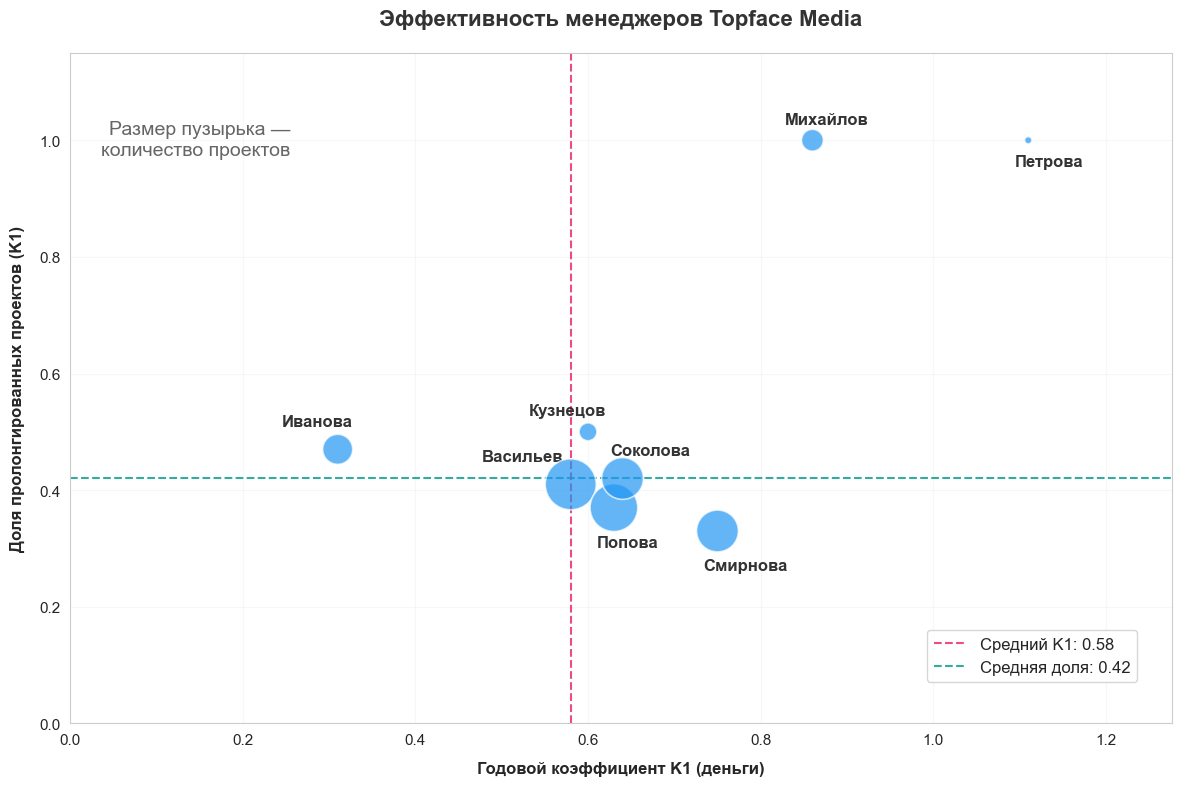

In [14]:
# ============================================
# НАСТРОЙКИ
# ============================================

# Позиции подписей фамилий (dx, dy в пунктах от точки)
LABEL_OFFSETS = {
    'Васильев':   (-35, 20),
    'Попова':     (10, -25),
    'Смирнова':   (20, -25),
    'Соколова':   (20, 20),
    'Иванова':    (-15, 20),
    'Михайлов':   (10, 15),
    'Кузнецов':   (-15, 15),
    'Петрова':    (15, -15),
    'Федорова':   (-15, -15)
}

# Позиция легенды (доли от ширины/высоты осей)
LEGEND_X = 0.77
LEGEND_Y = 0.05

# Позиция подписи "Размер пузырька — количество проектов"
BUBBLE_LABEL_X = 0.2
BUBBLE_LABEL_Y = 0.9

# Размер шрифта подписей фамилий
LABEL_FONT_SIZE = 12

# Масштаб пузырьков (1.0 = стандарт, 1.5 = в полтора раза крупнее)
BUBBLE_SCALE = 1.1

# ============================================
# ПОСТРОЕНИЕ ГРАФИКА
# ============================================

sns.set_style("whitegrid")
plt.rcParams['font.size'] = 11

plot_data = quality_out[~quality_out['Менеджер'].isin(['Все', 'без А/М'])].copy()
plot_data = plot_data[plot_data['Всего проектов за 2023'] > 0]
plot_data['Фамилия'] = plot_data['Менеджер'].str.split().str[0]

x = plot_data['K1 Коэффициент (деньги)']
y = plot_data['K1 Доля пролонгации']
size = plot_data['Всего проектов за 2023'] * 25 * BUBBLE_SCALE
labels = plot_data['Фамилия']

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(x, y, s=size, color='#2196F3', alpha=0.7,
                     edgecolors='white', linewidth=1.2, zorder=5)

# Подписи фамилий
for i, (xi, yi, label) in enumerate(zip(x, y, labels)):
    dx, dy = LABEL_OFFSETS.get(label, (10, 10))
    ax.annotate(label, (xi, yi),
                textcoords="offset points", xytext=(dx, dy),
                fontsize=LABEL_FONT_SIZE, color='#333333', fontweight='bold',
                ha='center', va='center')

# Средние по отделу
avg_k1 = quality_out[quality_out['Менеджер'] == 'Все']['K1 Коэффициент (деньги)'].values[0]
avg_rate = quality_out[quality_out['Менеджер'] == 'Все']['K1 Доля пролонгации'].values[0]

ax.axvline(avg_k1, color='#E91E63', linestyle='--', linewidth=1.5, alpha=0.8,
           label=f'Средний K1: {avg_k1:.2f}')
ax.axhline(avg_rate, color='#009688', linestyle='--', linewidth=1.5, alpha=0.8,
           label=f'Средняя доля: {avg_rate:.2f}')

# Оси от нуля
ax.set_xlim(0, max(x) * 1.15)
ax.set_ylim(0, max(y) * 1.15)

ax.set_xlabel('Годовой коэффициент K1 (деньги)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Доля пролонгированных проектов (K1)', fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('Эффективность менеджеров Topface Media', fontsize=16, pad=20, fontweight='bold', color='#333')

# Легенда с ручной позицией
ax.legend(fontsize=12, loc='lower left', frameon=True, facecolor='white', edgecolor='#ccc',
          bbox_to_anchor=(LEGEND_X, LEGEND_Y), bbox_transform=ax.transAxes)

ax.grid(True, alpha=0.15)

# Подпись про размер пузырька с ручной позицией
ax.text(BUBBLE_LABEL_X, BUBBLE_LABEL_Y, 'Размер пузырька —\nколичество проектов',
        transform=ax.transAxes,
        ha='right', va='top',
        fontsize=14, color='#666')

plt.tight_layout()
plt.show()

### Диаграмма с областями для общей динамики


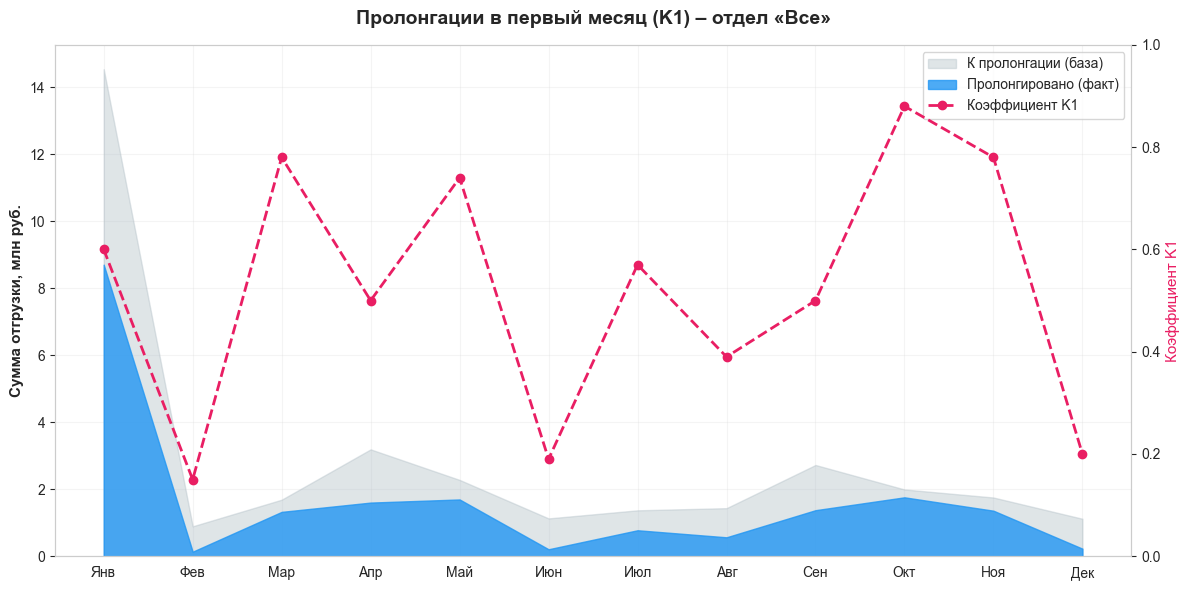

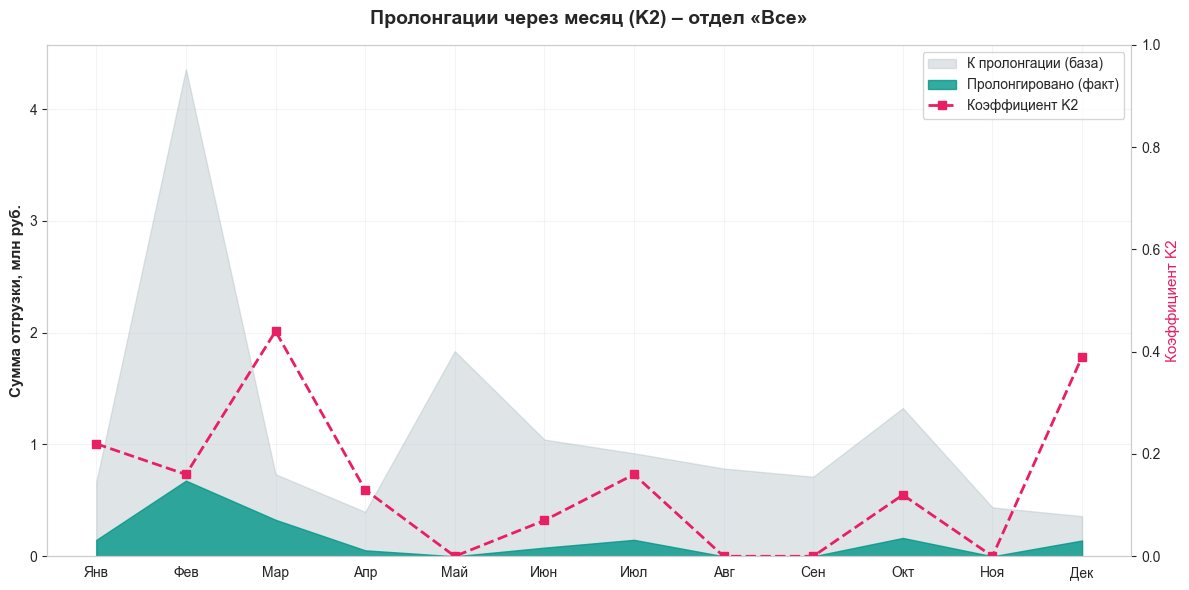

In [15]:

sns.set_style("whitegrid")
plt.rcParams['font.size'] = 10
plt.rcParams['font.family'] = 'sans-serif'

# Данные для "Все"
all_data = koef_df[koef_df['AM'] == 'Все'].sort_values('month').copy()
all_data['month_dt'] = pd.to_datetime(all_data['month'])

months_rus = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн',
              'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']

# Переводим в миллионы рублей
k1_denom_m = all_data['K1_denom'].values / 1e6
k1_num_m = all_data['K1_num'].values / 1e6
k2_denom_m = all_data['K2_denom'].values / 1e6
k2_num_m = all_data['K2_num'].values / 1e6

# Коэффициенты
k1_coef = [round(v, 2) if pd.notna(v) else None for v in all_data['K1']]
k2_coef = [round(v, 2) if pd.notna(v) else None for v in all_data['K2']]

# ============================================================
# ГРАФИК 1: K1 (первый месяц)
# ============================================================
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.fill_between(range(12), 0, k1_denom_m, color='#B0BEC5', alpha=0.4,
                 label='К пролонгации (база)')
ax1.fill_between(range(12), 0, k1_num_m, color='#2196F3', alpha=0.8,
                 label='Пролонгировано (факт)')

ax2 = ax1.twinx()
ax2.plot(range(12), k1_coef, color='#E91E63', linewidth=2, linestyle='--',
         marker='o', markersize=6, label='Коэффициент K1')
ax2.set_ylim(0, 1)
ax1.set_ylim(bottom=0)

# Убираем сетку с правой оси
ax2.grid(False)

ax1.set_xticks(range(12))
ax1.set_xticklabels(months_rus)
ax1.set_ylabel('Сумма отгрузки, млн руб.', fontweight='bold', fontsize=11)
ax2.set_ylabel('Коэффициент K1', fontsize=11, color='#E91E63')
ax1.set_title('Пролонгации в первый месяц (K1) – отдел «Все»', fontsize=14,
              fontweight='bold', pad=15)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right',
           frameon=True, facecolor='white')

ax1.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# ============================================================
# ГРАФИК 2: K2 (через месяц)
# ============================================================
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.fill_between(range(12), 0, k2_denom_m, color='#B0BEC5', alpha=0.4,
                 label='К пролонгации (база)')
ax1.fill_between(range(12), 0, k2_num_m, color='#009688', alpha=0.8,
                 label='Пролонгировано (факт)')

ax2 = ax1.twinx()
ax2.plot(range(12), k2_coef, color='#E91E63', linewidth=2, linestyle='--',
         marker='s', markersize=6, label='Коэффициент K2')
ax2.set_ylim(0, 1)
ax1.set_ylim(bottom=0)

# Убираем сетку с правой оси
ax2.grid(False)

ax1.set_xticks(range(12))
ax1.set_xticklabels(months_rus)
ax1.set_ylabel('Сумма отгрузки, млн руб.', fontweight='bold', fontsize=11)
ax2.set_ylabel('Коэффициент K2', fontsize=11, color='#E91E63')
ax1.set_title('Пролонгации через месяц (K2) – отдел «Все»', fontsize=14,
              fontweight='bold', pad=15)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right',
           frameon=True, facecolor='white')

ax1.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

«Высокие значения “к пролонгации” в январе–феврале 2023 связаны с большим количеством проектов (52 в декабре 2022) и крупными финальными платежами по завершающимся годовым контрактам. Это не ошибка, а отражение делового цикла.»

### Линейчатые. Менеджеры за год

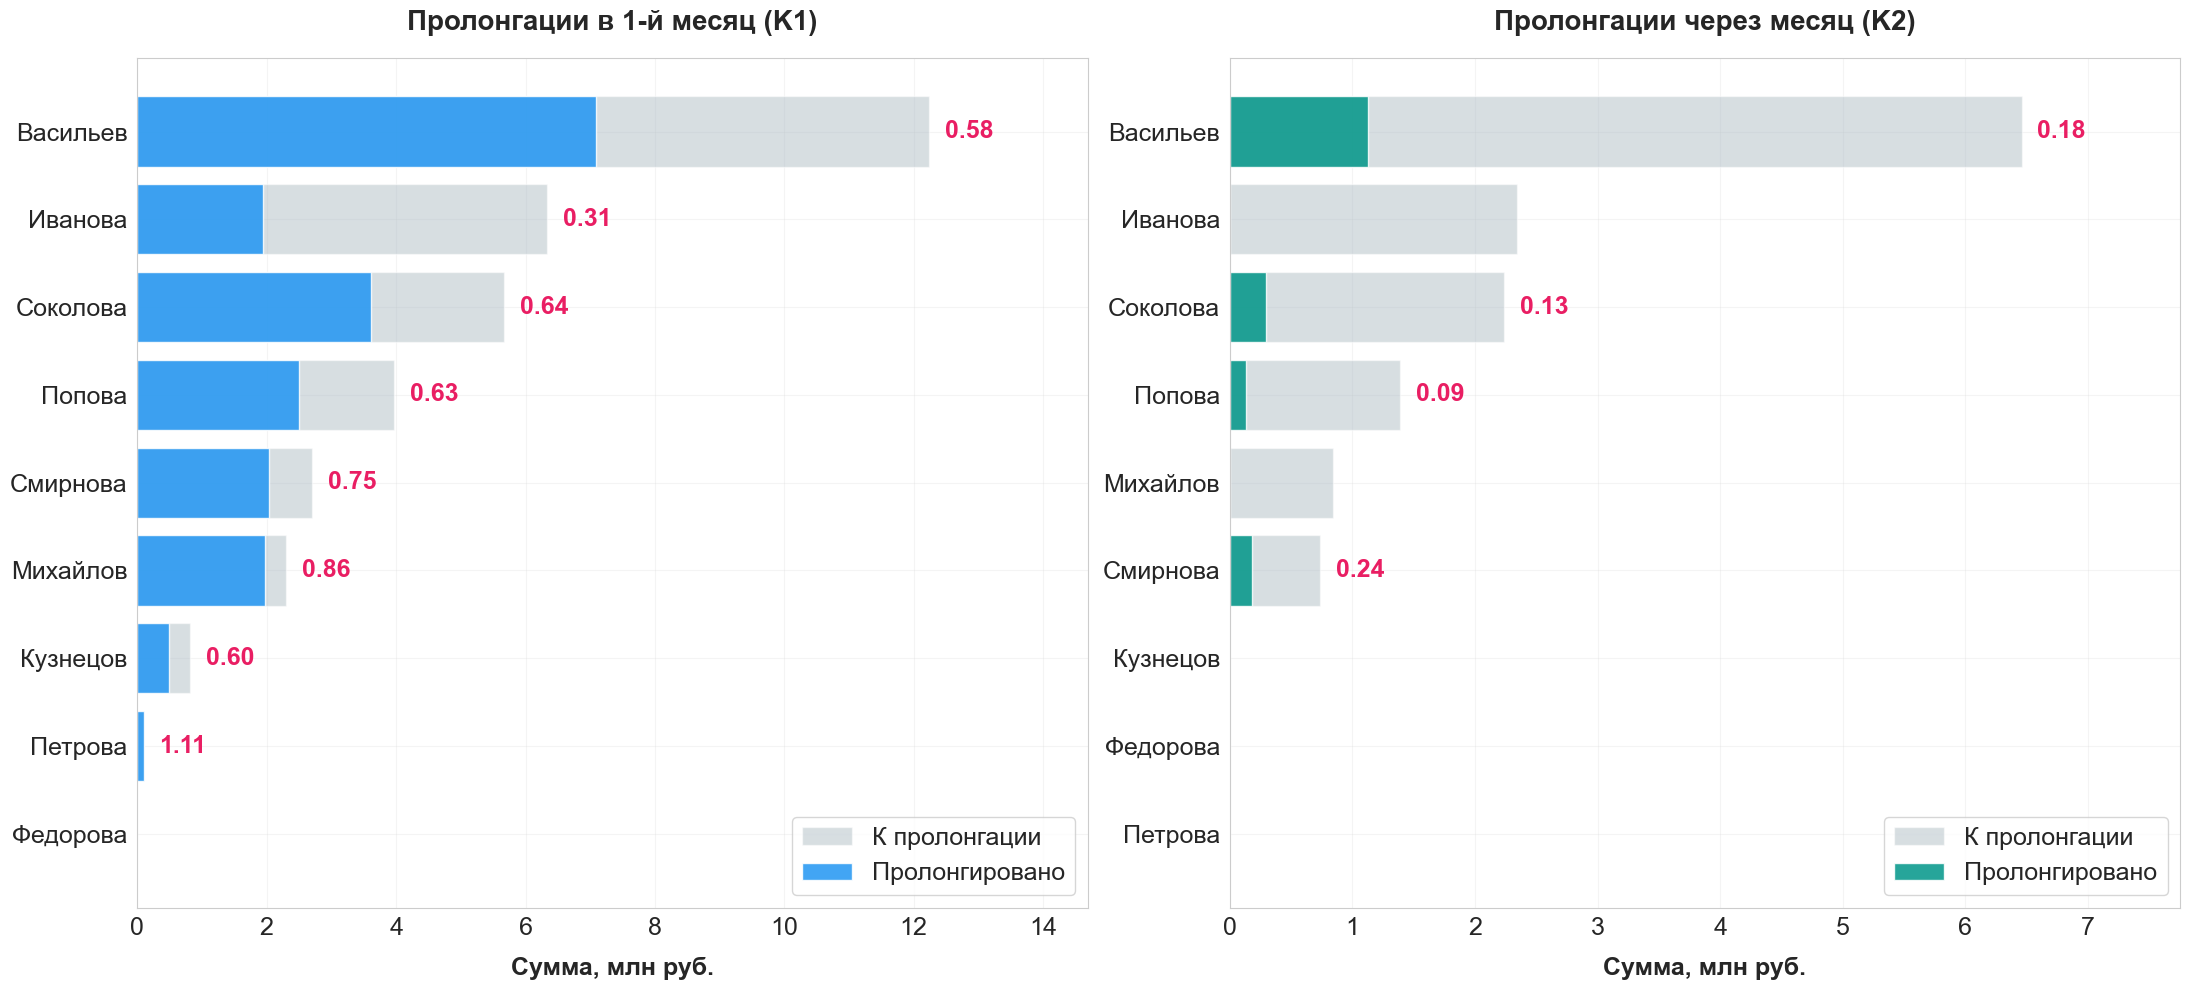

In [16]:
sns.set_style("whitegrid")

# Подготовка данных
plot_df = df_year[~df_year['Менеджер'].isin(['Все', 'без А/М'])].copy()

# K1
plot_k1 = plot_df.sort_values('к пролонгированию K1', ascending=True)
y_k1 = [m.split()[0] for m in plot_k1['Менеджер']]
bases_k1 = plot_k1['к пролонгированию K1'] / 1e6
facts_k1 = plot_k1['Пролонгировано K1'] / 1e6
coefs_k1 = plot_k1['Коэффициент K1']

# K2 (тоже в млн руб.)
plot_k2 = plot_df.sort_values('к пролонгированию K2', ascending=True)
y_k2 = [m.split()[0] for m in plot_k2['Менеджер']]
bases_k2 = plot_k2['к пролонгированию K2'] / 1e6
facts_k2 = plot_k2['Пролонгировано K2'] / 1e6
coefs_k2 = plot_k2['Коэффициент K2']

# ============================================================
# ДВЕ ДИАГРАММЫ РЯДОМ
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))

# ---------- K1 ----------
ax1.barh(y_k1, bases_k1, color='#B0BEC5', alpha=0.5, label='К пролонгации')
ax1.barh(y_k1, facts_k1, color='#2196F3', alpha=0.85, label='Пролонгировано')

for i, (base_val, coef) in enumerate(zip(bases_k1, coefs_k1)):
    if pd.notna(coef) and coef != '':
        ax1.text(base_val + max(bases_k1) * 0.02, i, f'{coef:.2f}',
                 va='center', fontsize=18, color='#E91E63', fontweight='bold')

ax1.set_xlabel('Сумма, млн руб.', fontsize=18, fontweight='bold', labelpad=12)
ax1.set_title('Пролонгации в 1-й месяц (K1)', fontsize=20, fontweight='bold', pad=20)
ax1.legend(loc='lower right', frameon=True, facecolor='white', fontsize=18)
ax1.grid(True, alpha=0.2)
ax1.set_xlim(0, max(bases_k1) * 1.2)
ax1.tick_params(labelsize=18)

# ---------- K2 ----------
ax2.barh(y_k2, bases_k2, color='#B0BEC5', alpha=0.5, label='К пролонгации')
ax2.barh(y_k2, facts_k2, color='#009688', alpha=0.85, label='Пролонгировано')

for i, (base_val, coef) in enumerate(zip(bases_k2, coefs_k2)):
    if pd.notna(coef) and coef != '' and coef > 0:
        ax2.text(base_val + max(bases_k2) * 0.02, i, f'{coef:.2f}',
                 va='center', fontsize=18, color='#E91E63', fontweight='bold')

ax2.set_xlabel('Сумма, млн руб.', fontsize=18, fontweight='bold', labelpad=12)
ax2.set_title('Пролонгации через месяц (K2)', fontsize=20, fontweight='bold', pad=20)
ax2.legend(loc='lower right', frameon=True, facecolor='white', fontsize=18)
ax2.grid(True, alpha=0.2)
ax2.set_xlim(0, max(bases_k2) * 1.2)
ax2.tick_params(labelsize=18)

plt.tight_layout()
plt.show()

### Тепловые карты. Менеджеры по месяцам.

C:\Users\urize\AppData\Local\Temp\ipykernel_20036\649489227.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  k1_data = pivot_k1.replace('', np.nan).astype(float)
C:\Users\urize\AppData\Local\Temp\ipykernel_20036\649489227.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  k2_data = pivot_k2.replace('', np.nan).astype(float)


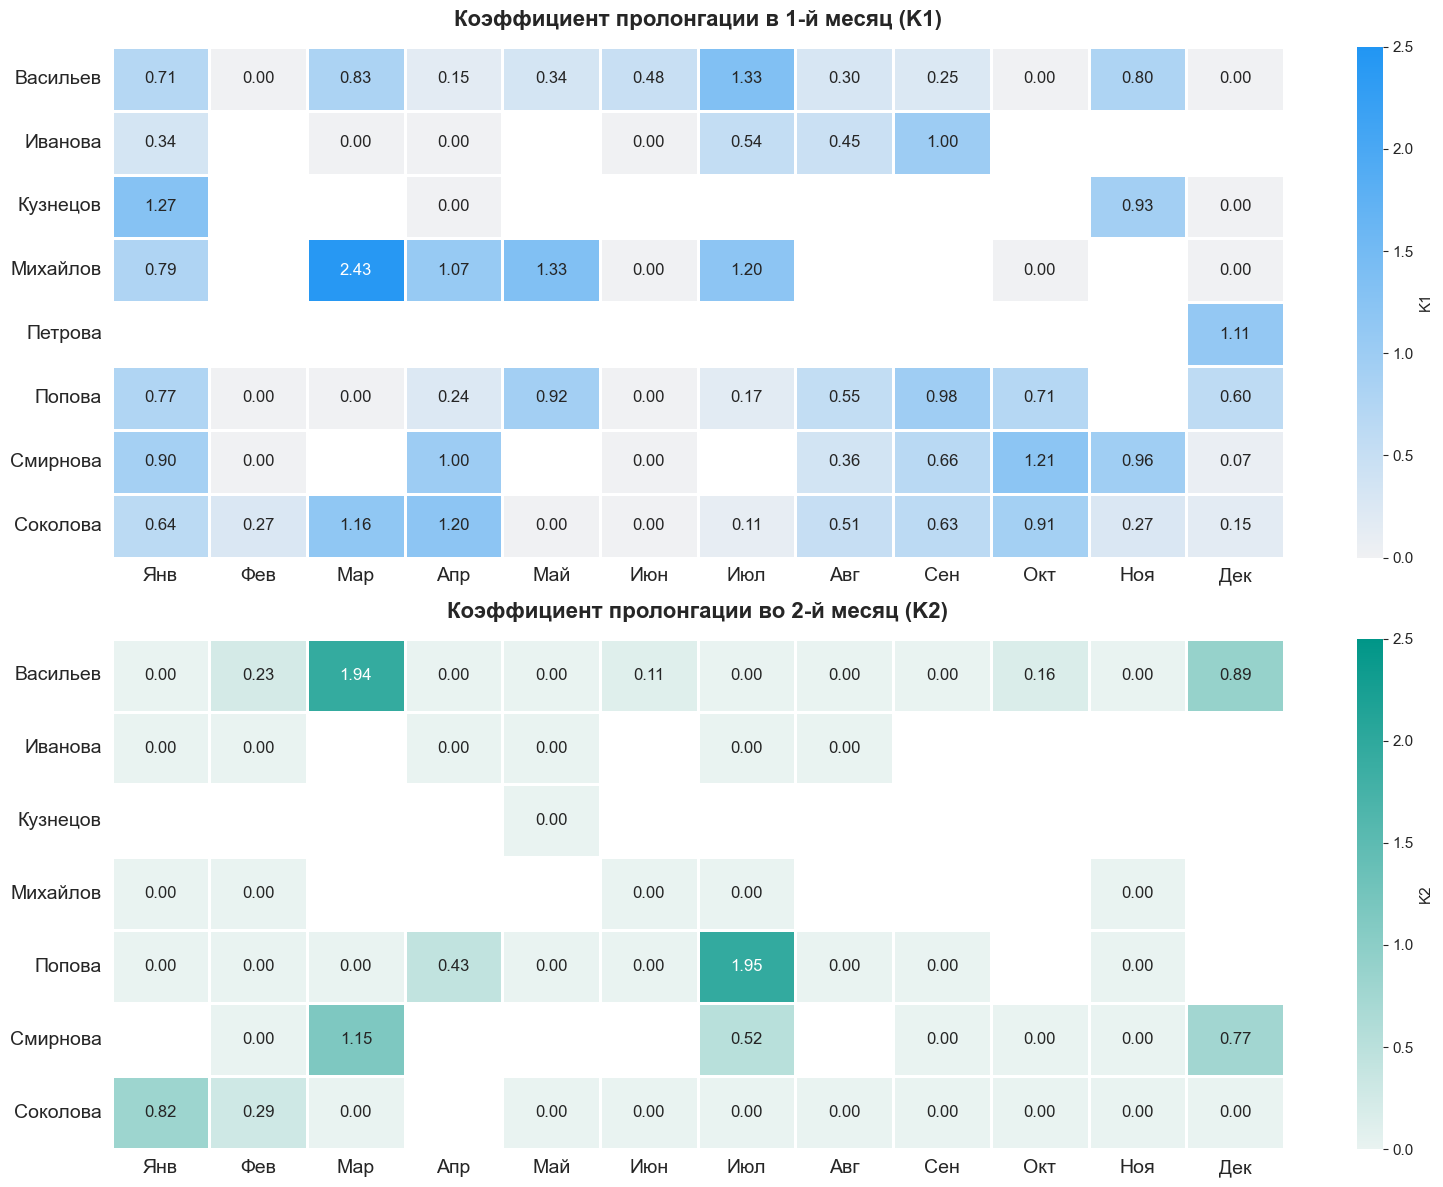

In [20]:
sns.set_style("white")
plt.rcParams['font.size'] = 11

# Подготовка данных
k1_data = pivot_k1.replace('', np.nan).astype(float)
k2_data = pivot_k2.replace('', np.nan).astype(float)

# Оставляем только фамилии
k1_data.index = [idx.split()[0] for idx in k1_data.index]
k2_data.index = [idx.split()[0] for idx in k2_data.index]

# Убираем лишних
k1_data = k1_data.drop(['без', 'Все', 'Федорова'], errors='ignore')
k2_data = k2_data.drop(['без', 'Все', 'Федорова'], errors='ignore')

# Русские названия месяцев
months_ru = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн',
             'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']
k1_data.columns = months_ru
k2_data.columns = months_ru

# Цветовые палитры
cmap_k1 = sns.light_palette("#2196F3", as_cmap=True)
cmap_k2 = sns.light_palette("#009688", as_cmap=True)

# ============================================================
# ДВЕ ТЕПЛОВЫЕ КАРТЫ ОДНА ПОД ДРУГОЙ
# ============================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

# --- K1 ---
sns.heatmap(k1_data, annot=True, fmt='.2f', cmap=cmap_k1,
            linewidths=0.8, linecolor='white', cbar_kws={'label': 'K1'},
            mask=k1_data.isna(), ax=ax1, annot_kws={'fontsize': 12},
            vmin=0, vmax=2.5)
ax1.set_title('Коэффициент пролонгации в 1-й месяц (K1)', fontsize=16, fontweight='bold', pad=15)
ax1.set_xlabel('')
ax1.set_ylabel('')
ax1.tick_params(axis='both', labelsize=14)

# --- K2 ---
sns.heatmap(k2_data, annot=True, fmt='.2f', cmap=cmap_k2,
            linewidths=0.8, linecolor='white', cbar_kws={'label': 'K2'},
            mask=k2_data.isna(), ax=ax2, annot_kws={'fontsize': 12},
            vmin=0, vmax=2.5)
ax2.set_title('Коэффициент пролонгации во 2-й месяц (K2)', fontsize=16, fontweight='bold', pad=15)
ax2.set_xlabel('')
ax2.set_ylabel('')
ax2.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.show()

## ОБЩАЯ КАРТИНА

Отдел в целом пролонгирует 58% денег и 42% проектов в первый месяц после завершения. Это неплохой базовый уровень, но почти половина проектов теряется сразу. Через месяц возвращается лишь 13% денег и 7% проектов — «догоняющая» пролонгация практически не работает.

---

**ЛИДЕРЫ**

- **Михайлов** — лучший менеджер. 9 проектов, все 9 пролонгированы в первый месяц (100%), возврат денег 86%. Работает стабильно и качественно. Рекомендация: изучить его подход, масштабировать на отдел.
- **Смирнова** — самая высокая эффективность по деньгам (K1 = 75%) и лучшая «догоняющая» пролонгация (K2 = 24%). Возвращает клиентов даже через месяц. Рекомендация: назначить наставником по работе с «трудными» клиентами.

**СЕРЕДНЯКИ**

- **Васильев** — самый большой портфель (49 проектов). Показатели близки к среднему по отделу (K1 = 58%, доля 41%). Стабильный работник, но без выдающихся результатов. Рекомендация: проанализировать, почему 29 проектов не пролонгируются — возможно, перегрузка.
- **Попова** — 43 проекта, K1 = 63%, но доля пролонгированных проектов низкая (37%). Хорошо возвращает деньги по небольшой части клиентов, но большинство теряет. Рекомендация: провести аудит клиентской базы, выявить закономерности потерь.
- **Соколова** — 33 проекта, показатели ровные, без провалов. Надёжный сотрудник. Рекомендация: может быть хорошим наставником для новичков.

**ЗОНА РИСКА**

- **Иванова** — главная проблема отдела. 17 проектов, K1 = 31% (вдвое ниже среднего!), K2 = 0. Теряет клиентов и не возвращает их. При этом доля проектов 47% означает, что она пытается пролонгировать, но суммы крайне низкие — возможно, соглашается на невыгодные условия. Рекомендация: срочный разбор портфеля, дополнительное обучение или перераспределение клиентов.

**МАЛЫЙ ПОРТФЕЛЬ**

- **Кузнецов** — 6 проектов, показатели средние. Мало данных для выводов. Рекомендация: передать больше проектов для оценки реальной эффективности.
- **Петрова** — 1 проект, K1 = 111%. Формально лучший результат, но статистически незначим. Рекомендация: загрузить работой, оценить на большем объёме.
- **Федорова** — 1 проект, 0 пролонгаций. Либо проект не предполагал продления, либо клиент упущен. Рекомендация: выяснить причину.

---

**КЛЮЧЕВЫЕ РЕКОМЕНДАЦИИ ДЛЯ РУКОВОДСТВА**

1. **Пересмотреть методику K2.** Сейчас K2 работает только у 4 из 8 менеджеров. Предлагаю расширить окно «догоняющей» пролонгации до 3–6 месяцев, чтобы видеть реальную картину возврата клиентов.

2. **Ввести комбинированный KPI:** годовой K1 (деньги) + доля пролонгированных проектов. Это исключит ситуацию, как у Петровой (один проект даёт 111%, но это не показатель стабильности).

3. **Дифференцировать нагрузку.** У Васильева 49 проектов, у Михайлова 9. Возможно, качество пролонгации страдает от перегрузки. Рекомендую сбалансировать портфели.

4. **Провести разбор клиентов Ивановой.** 17 проектов с K1 = 31% — это прямые потери для бизнеса. Нужно понять: проблема в навыках, в сложности клиентов или в невыгодных условиях пролонгации.

5. **Изучить опыт лидеров.** Михайлов (100% проектов) и Смирнова (K2 = 24%) обладают эффективными техниками. Провести серию внутренних воркшопов с их участием.

6. **Внедрить систему раннего предупреждения.** Если менеджер не пролонгирует проект в первый месяц, автоматически запускать эскалацию — подключение наставника или руководителя для «догоняющей» работы с клиентом.

---

**ИТОГ**

Отдел работает удовлетворительно, но имеет значительный резерв роста за счёт решения проблем Ивановой, перераспределения нагрузки и масштабирования лучших практик Михайлова и Смирновой. Рекомендую повторить анализ через квартал после внедрения изменений.